# Stereographic projection

$$
n_x = \frac{w + \bar{w}}{1+\bar{w}w} \qquad n_y = -i \frac{w - \bar{w}}{1+\bar{w}w} \qquad n_z = \frac{1-\bar{w}w}{1+\bar{w}w} 
$$

The inverse mapping is

$$
|w|^2 = \frac{1-n_z}{1+n_z} \qquad w = \frac{n_x + i n_y}{1+n_z}
$$

In the new coordinates :
$$
\vec{n} \cdot \vec{n}' = \frac{2w \bar{w}'+2\bar{w}w'+(1-\bar{w}w)(1-\bar{w}'w')}{(1+\bar{w}w)(1+\bar{w}'w')}
$$
and
$$
\partial_w (\vec{n} \cdot \vec{n}') = 2\; \frac{\bar{w}' - \bar{w}^2 w' - \bar{w}(1-\bar{w'}w')}{(1+\bar{w}w)^2 \cdot (1+\bar{w'}w')}
$$

In [2]:
using Pkg
Pkg.activate("..")   # activate project environment

using Plots
using LaTeXStrings
using DataFrames

using Revise # automatically sync src updates ----> suuuuuper important for development
using SkyrmionTunneling
const ST = SkyrmionTunneling # alias for easier referencing

  Activating project at `~/Documents/GitHub/skyrmion-tunnelling`


SkyrmionTunneling

In [3]:
ST.test_energy_functional()

E_ferromagnetic = 0 -------> OK

H is Sz invariant -------> OK

H vector and H stereographic consistent -------> OK


# Triangular Lattice

In [32]:
lattice = TriangularLattice(30,30)
J1 = 1.0; J2 = -0.5; J3 = 0.0
K = 0.4
B = ST.uniform_B(0.2,lattice)

params = HamiltonianParameters(J1,J2,J3,K,B)
boundary = PeriodicBoundary()

system1 = System(params,lattice,boundary)
ST.describe_system(system1)

TriangularLattice(30, 30)
PeriodicBoundary()
Hamiltonian parameters:
J1 = 1.0	J2 = -0.5	J3 = 0.0
K = 0.4
B_avg = 0.2	B_uniform = true



Launching LLG relaxation for


Progress:   0%|▏                                        |  ETA: 0:00:43

TriangularLattice(30, 30)
PeriodicBoundary()
Hamiltonian parameters:
J1 = 1.0	J2 = -0.5	J3 = 0.0
K = 0.4
B_avg = 0.2	B_uniform = true



Progress: 100%|█████████████████████████████████████████| Time: 0:00:28


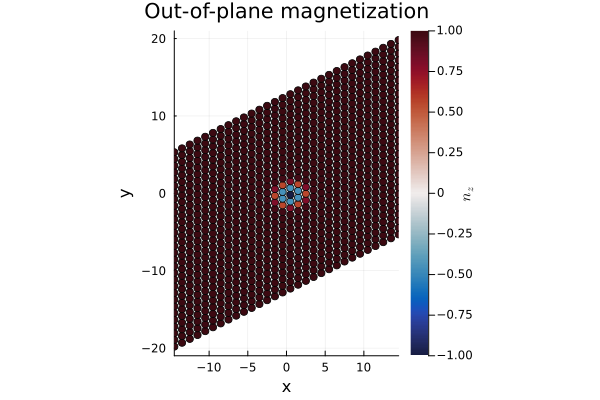

total charge Q = 0.6594558853023389

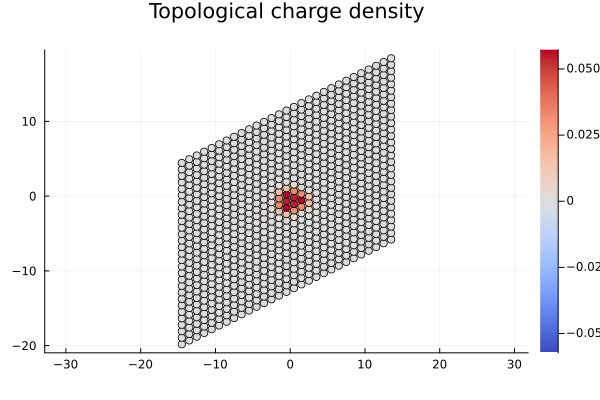

3×30×30 Array{Float64, 3}:
[:, :, 1] =
 -0.000123314  -0.000192727  -0.000188894  …   0.000123334   1.22745e-8
  5.75001e-5    7.64362e-5    5.20655e-5      -5.75089e-5   -6.12072e-9
  1.0           1.0           1.0              1.0           1.0

[:, :, 2] =
 -1.05738e-6  -9.52467e-5  -0.000136194  …   0.000203304   0.000119281
 -2.11231e-6   4.13505e-5   4.53952e-5      -0.00010308   -6.5503e-5
  1.0          1.0          1.0              1.0           1.0

[:, :, 3] =
  8.96614e-5  3.19944e-6  -4.27841e-5  …   0.000179958   0.000175566
 -5.24054e-5  6.29283e-6   2.85638e-5     -0.000107397  -0.0001103
  1.0         1.0          1.0             1.0           1.0

;;; … 

[:, :, 28] =
 -5.91437e-5   0.000217845   0.000589647  …  -0.000117108  -0.000153635
  5.68145e-5  -0.000120357  -0.000298967      8.30356e-5    0.000121606
  1.0          1.0           1.0              1.0           1.0

[:, :, 29] =
 -0.000179972  -3.86489e-5   0.000225835  …  -8.96465e-5  -0.00017556
  0.00010740

In [33]:
n_Sk = ST.skyrmion(system1)

In [40]:
if true || minimum(n_Sk[3,:,:]) < -0.95
    ind = argmin(n_Sk[3,:,:])
    println("WARNING ---> Spin down at ", ind)
    theta = pi-0.1
    phi = pi # this is very important, too!!!
    n_Sk[:,ind] = [sin(theta)*cos(phi), sin(theta)*sin(phi), cos(theta)]
end
minimum(n_Sk[3,:,:])

WARNING ---> Spin down at CartesianIndex(15, 16)


-0.9950041652780257

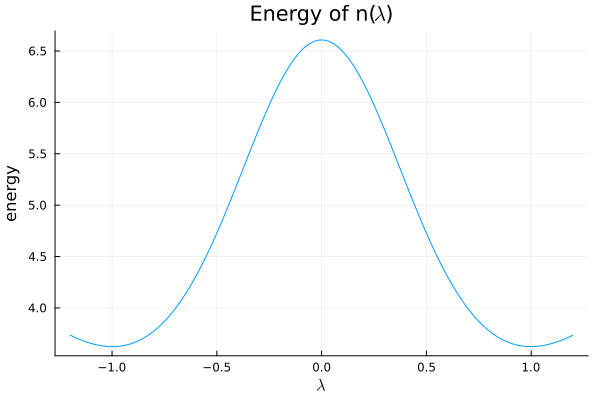

Imaginary part = 82.94315640404999
WARNING ----> imaginary part is nonzero !!!!! ---------> It gets neglected via a real projection


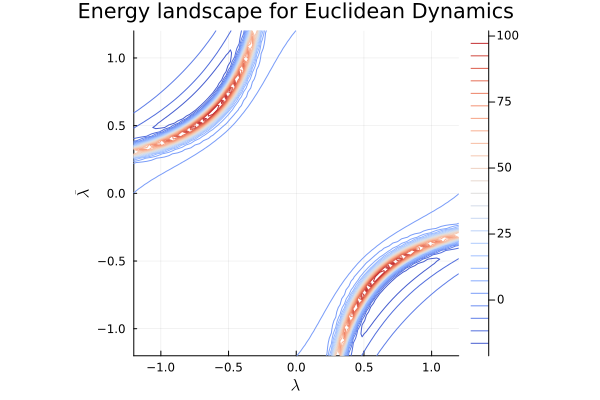

Imaginary part = 15.269817787979687
WARNING ----> imaginary part is nonzero !!!!! ---------> It gets neglected via a real projection


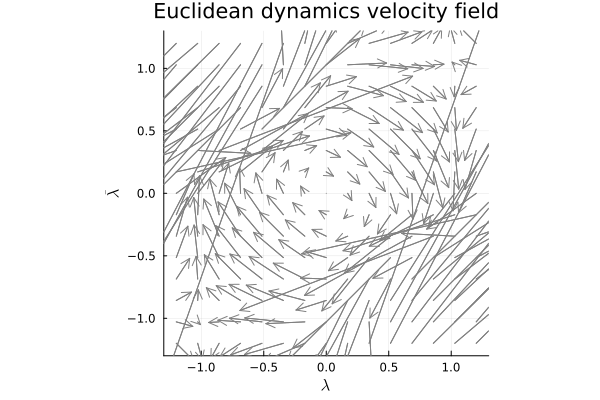

In [41]:
coord=LambdaCoordinate(ST.w_project(n_Sk))
ST.describe_collective_coordinate(system1, coord, xmin=-1.2, xmax=1.2)

The saddle point is at 0.9989791693523318 - 1.6295758668652553e-6im
The instantonic trajectory passes through the point 
 x = 0.9491274279832687

Progress:   2%|▊                                        |  ETA: 0:00:06

 - 3.9156212496270665e-7im
 y = 1.00283354199917 - 1.2251165056724177e-5im
sanity check : |H_inst-H0| = 5.4569874524489085e-12
-- Integrating forwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:04
Progress:   2%|▉                                        |  ETA: 0:00:04

-- Integrating backwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:04


imaginary = 0.06502827796079837


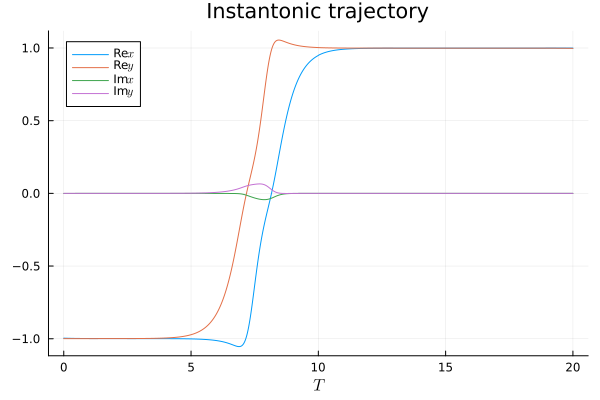

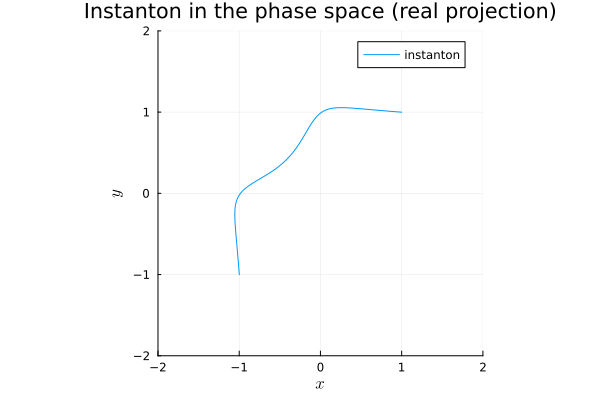


Total action = 16.24034680185998 + 0.6085868922328294im


(16.24034680185998 + 0.6085868922328294im, ComplexF64[-0.9959439301587659 - 0.0005002442198358694im -0.996000420253525 - 0.0004909691829338667im … 0.999091759605642 - 3.4788345609090667e-6im 0.9990939034911639 - 3.5135868431528165e-6im; -0.9992087947136101 + 3.98118144742423e-5im -0.9992044263062044 + 3.9105095672408295e-5im … 0.997501796123091 + 2.618720515042972e-5im 0.9974737787885252 + 2.6652842158411737e-5im])

In [42]:
S_inst, sol = ST.instanton(system1,coord, x_init = 1.0, direction_guess=[-0.05, 0.00], T_backward=10.0, T_forward=10.0, dt=0.01)

The saddle point is at 0.9989791693523318 - 1.6295758668652553e-6im
The instantonic trajectory passes through the point 
 x = 0.9491274279832687

Progress:   3%|█▏                                       |  ETA: 0:00:03

 - 3.9156212496270665e-7im
 y = 1.00283354199917 - 1.2251165056724177e-5im
sanity check : |H_inst-H0| = 5.4569874524489085e-12
-- Integrating forwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:03
Progress:   2%|█                                        |  ETA: 0:00:04

-- Integrating backwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:04


imaginary = 0.0


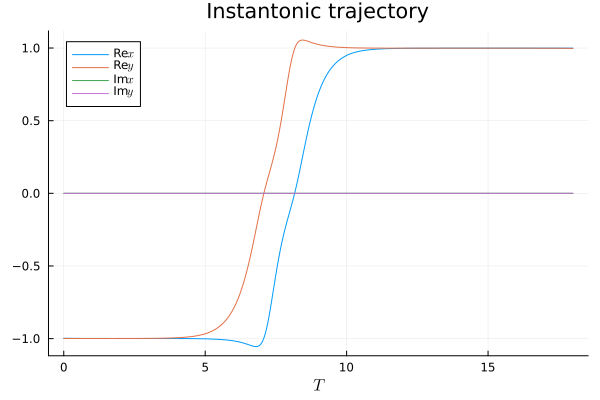

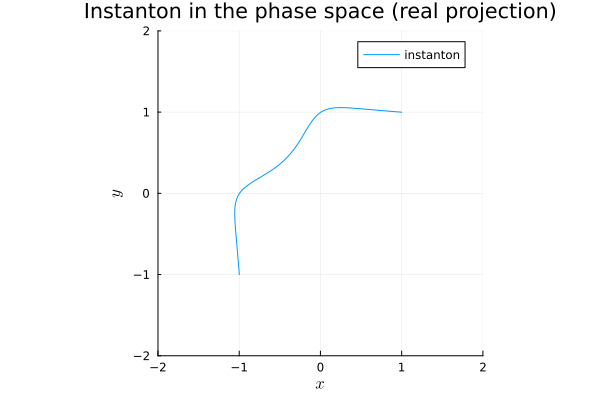


Total action = 16.1629298957273 - 2.3720732262826716im


(16.1629298957273 - 2.3720732262826716im, ComplexF64[-0.9973905111299408 + 0.0im -0.9974200859950911 + 0.0im … 0.9990799512720939 + 0.0im 0.999081871619254 + 0.0im; -0.999097576705948 + 0.0im -0.9990952623788069 + 0.0im … 0.9976559185666923 + 0.0im 0.9976308241200899 + 0.0im])

In [43]:
S_inst, sol = ST.instanton_force_real(system1,coord, x_init = 1.0, direction_guess=[-0.05, 0.00], T_backward=10.0, T_forward=8.0, dt=0.01)

# Square Lattice

Progress:   0%|                                         |  ETA: 0:01:45

Launching LLG relaxation for
SquareLattice(40, 40)
PeriodicBoundary()
Hamiltonian parameters:
J1 = 1.0	J2 = -0.3	J3 = -0.2
K = 0.02
B_avg = 0.2	B_uniform = true



Progress:  23%|█████████▌                               |  ETA: 0:00:43

could not find an improving step; stopped early


Progress: 100%|█████████████████████████████████████████| Time: 0:00:13


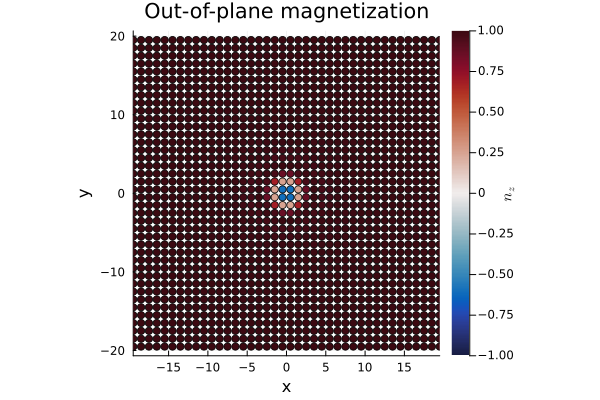

total charge Q = 0.6491536625094914

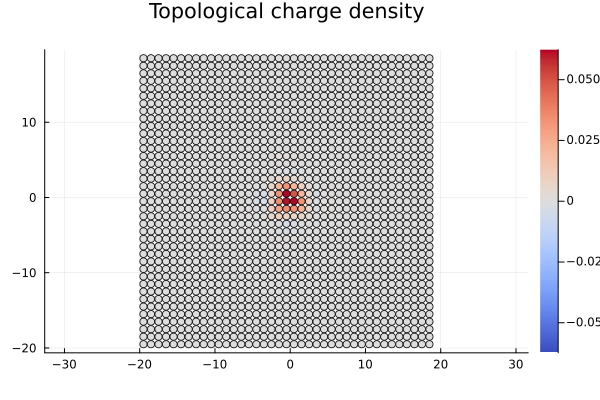

LambdaCoordinate{Matrix{ComplexF64}}(ComplexF64[0.0024499445793962848 + 0.002449944579393956im 0.00568924622158685 + 0.0009134504802011095im … -0.00568924622158044 + 0.0009134504801725786im -0.0024499445793829903 + 0.0024499445794095714im; 0.0009134504801969793 + 0.005689246221600231im 0.002023698881326655 + 0.002023698881321779im … -0.0020236988813187077 + 0.0020236988813518322im -0.0009134504801777032 + 0.005689246221583795im; … ; 0.0009134504801750334 - 0.005689246221595674im 0.002023698881339281 - 0.0020236988813148067im … -0.0020236988813432007 - 0.002023698881356728im -0.0009134504801856253 - 0.005689246221584406im; 0.002449944579401256 - 0.00244994457938402im 0.005689246221577124 - 0.0009134504801839386im … -0.005689246221575881 - 0.0009134504801852715im -0.0024499445794006875 - 0.0024499445794123596im])

In [5]:
lattice = SquareLattice(40,40)
J1 = 1.0;	J2 = -0.3;	J3 = -0.2
K = 0.02
B_avg = 0.2;	B = ST.uniform_B(B_avg,lattice)

params = HamiltonianParameters(J1,J2,J3,K,B)
boundary = PeriodicBoundary()
system2 = System(params,lattice,boundary)

n_Sk = ST.skyrmion(system2, annealing=false, LLG_relax=true, show_result=true)
coord = LambdaCoordinate(ST.w_project(n_Sk))

### $\lambda$ coordinate

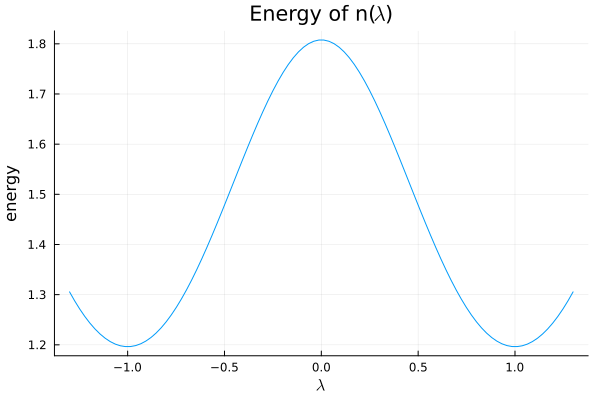

Imaginary part = 4.9474400779252106e-14


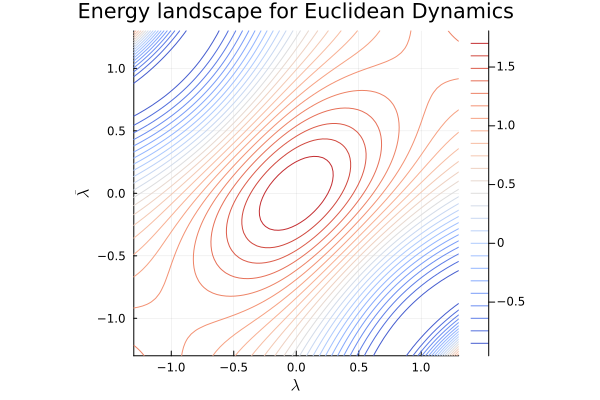

Imaginary part = 3.8802660567376563e-13


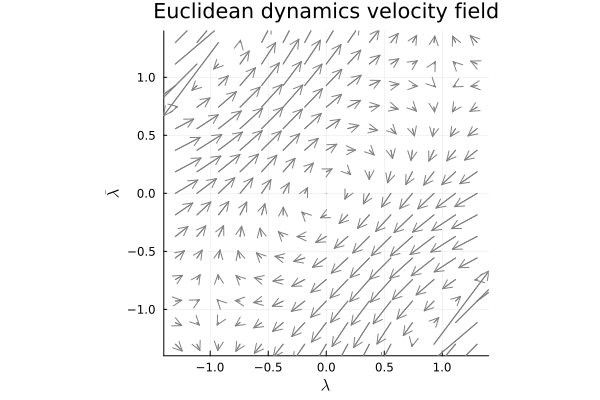

In [73]:
ST.describe_collective_coordinate(system2,coord, xmin=-1.3, xmax=1.3)

In [74]:
x0 = ST.find_saddle(system2,coord, initial_guess=1.0, max_steps=10)

1.0000000000013145 + 4.999098833841852e-21im

In [75]:
#ST.show_double_well_in_complex_plane(system2,coord, xmin=-1.3, xmax=1.3, N_points=75)

The saddle point is at 1.0000000000013145 + 4.999098833841852e-21im
The instantonic trajectory passes through the point 
 x = 0.9500044901292121

Progress:   1%|▎                                        |  ETA: 0:00:17

 + 3.979853602859481e-17im
 y = 0.9993290243177844 - 1.7698495849979742e-15im
sanity check : |H_inst-H0| = 1.7735146684619647e-11
-- Integrating forwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:16
Progress:   1%|▎                                        |  ETA: 0:00:15

-- Integrating backwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:16


imaginary = 2.0630116862101454e-11


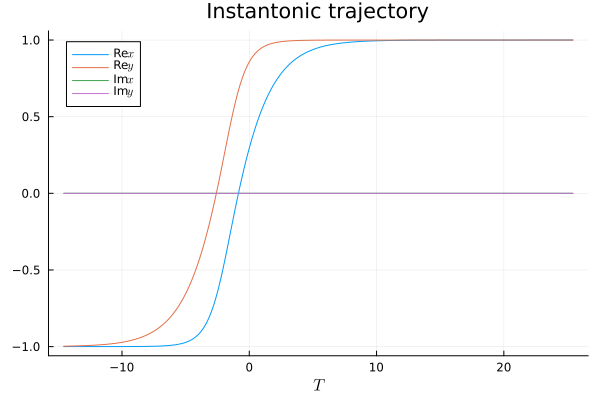

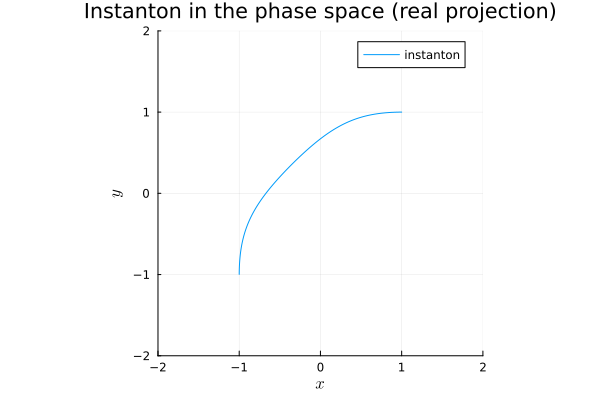


Total action = 7.597594396424502 - 8.999363764102539e-11im


(7.597594396424502 - 8.999363764102539e-11im, ComplexF64[-0.9999866372793293 - 8.89974260874477e-15im -0.999986558600321 - 8.84153905386343e-15im … 0.9999990429365314 + 1.010711683909256e-13im 0.9999990521435705 + 1.01578772325041e-13im; -0.9973273310664443 - 2.752356427692487e-15im -0.9973135353809628 - 2.7521784596205693e-15im … 1.0000184244544914 + 2.052413754339098e-11im 1.0000185162344037 + 2.0630116862101454e-11im])

In [76]:
S_inst, sol = ST.instanton(system2,coord, x_init = 1.0, direction_guess=[-0.05, 0.00], T_backward=20.0, T_forward=20.0, dt=0.01)

## $\eta$ coordinate

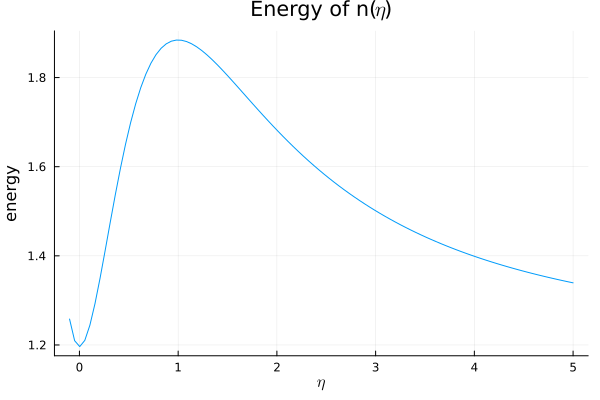

Imaginary part = 0.3725779803567647
WARNING ----> imaginary part is nonzero !!!!! ---------> It gets neglected via a real projection


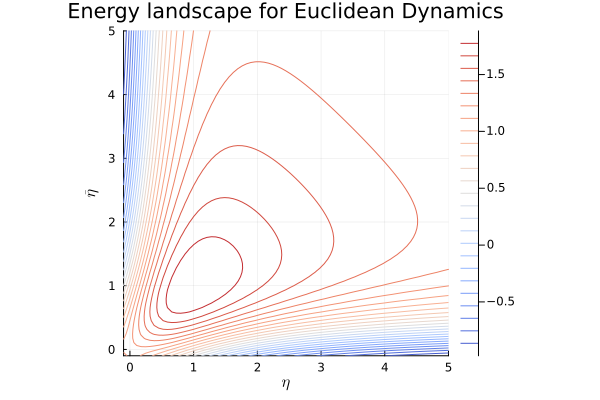

Imaginary part = 3.8160158088463225
WARNING ----> imaginary part is nonzero !!!!! ---------> It gets neglected via a real projection


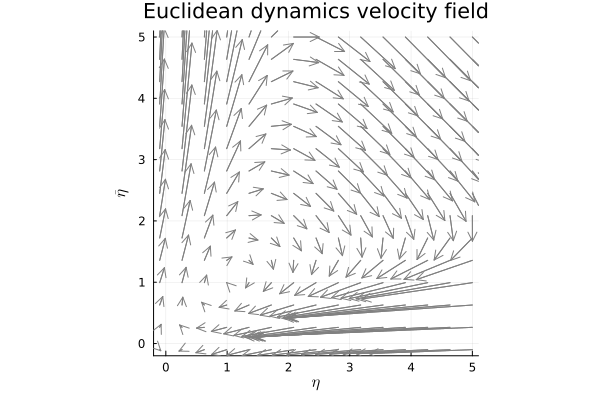

In [6]:
up, vp = ST.uv(n_Sk)
helicity = 0.24 # In theory, 0.0 should be no special value
n_aSk = ST.rotate_around_z( ST.reflect_y(n_Sk), helicity)
um, vm = ST.uv(n_aSk)

coord = EtaCoordinate(up,um,vp,vm)
ST.describe_collective_coordinate(system2, coord,xmin=-0.1, xmax=5.0)

The saddle point is at -7.166829833427536e-13 + 8.287271681493597e-21im
The instantonic trajectory passes through the point 
 x = 0.00024107668380668096

Progress:   3%|█▎                                       |  ETA: 0:00:03

 - 0.0032195035221391894im
 y = 0.04989621621073435 + 4.4637019864561046e-5im
sanity check : |H_inst-H0| = 5.163242212703472e-12
-- Integrating forwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress:   6%|██▋                                      |  ETA: 0:00:02

-- Integrating backwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


imaginary = 6.966186781375916


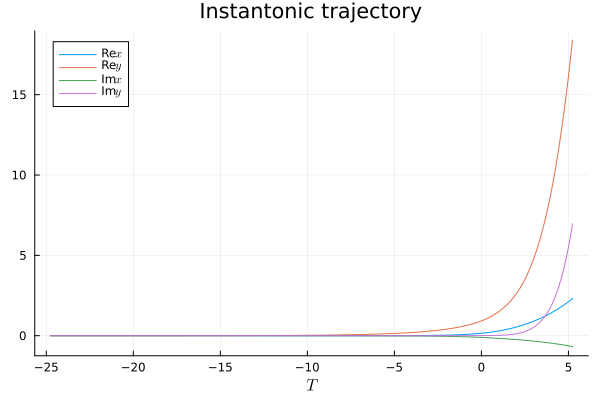

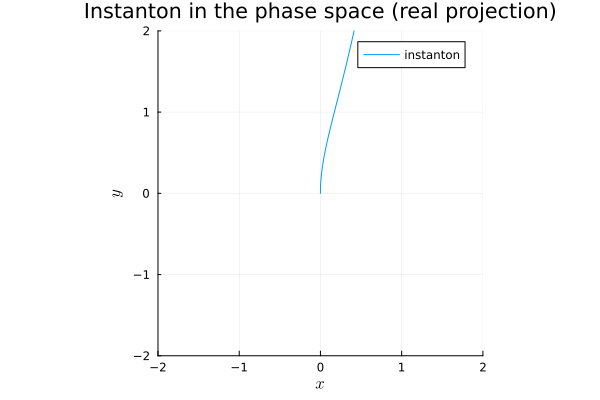

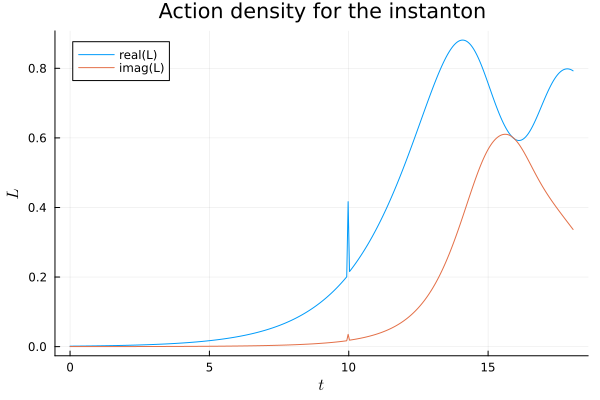


Total action = 5.527556920103599 + 2.4825959831673146im


(5.527556920103599 + 2.4825959831673146im, ComplexF64[-3.1102497305286363e-6 - 1.7158804496114156e-5im -3.180708986904307e-6 - 1.760470946368151e-5im … 2.2426692826219345 - 0.6597679794229875im 2.315045680166059 - 0.6770897262737834im; 0.000290792529439619 + 1.8395092927000558e-7im 0.0002983326846869063 + 1.897953035475177e-7im … 17.57215303389767 + 6.415403993831914im 18.399892925858108 + 6.966186781375916im])

In [8]:
S_inst, sol = ST.instanton(system2,coord, x_init = 0.0, direction_guess=[0.00, 0.05], T_backward=10.0, T_forward=20.0, dt=0.05, show_action=true)

## FM Tunneling

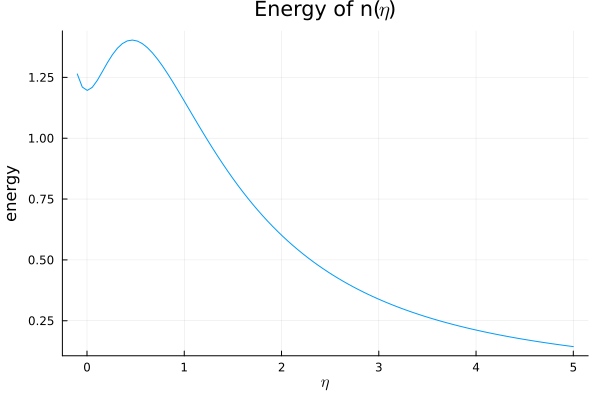

Imaginary part = 5.510560143557482e-16


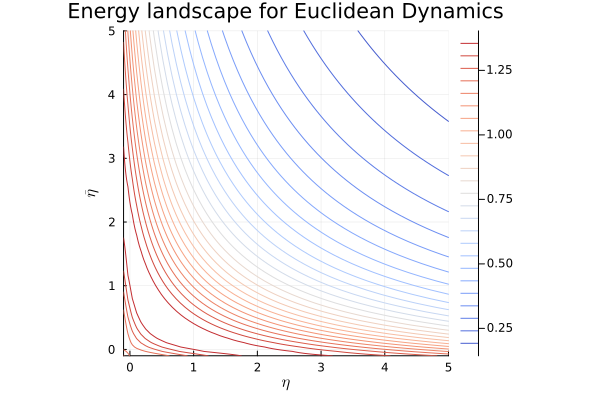

Imaginary part = 1.5397407572047886e-15


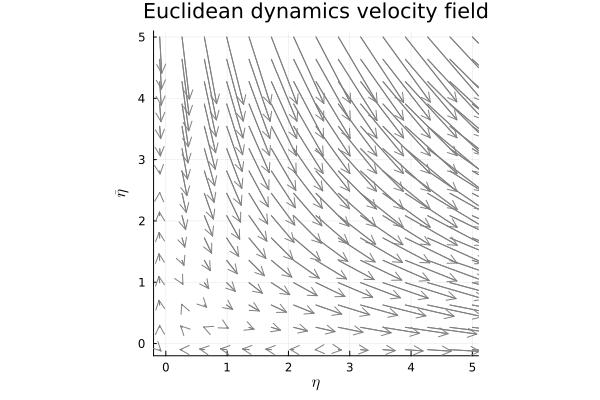

In [18]:
up, vp = ST.uv(n_Sk)
um, vm = ST.uv(ST.ferromagnetic(lattice))

coord = EtaCoordinate(up,um,vp,vm)
ST.describe_collective_coordinate(system2, coord,xmin=-0.1, xmax=5.0)

The saddle point is at -1.1360185228486695e-11 - 1.0173986125951564e-21im
The instantonic trajectory passes through the point 
 x = -0.011646645533375879 + 1.5461844850966502e-18im
 y = 0.04862983152110541 + 7.164232764791821e-18im
sanity check : |H_inst-H0| = 1.5006662579253616e-11
-- Integrating forwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:02


-- Integrating backwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


imaginary = 2.3020531480420057e-15


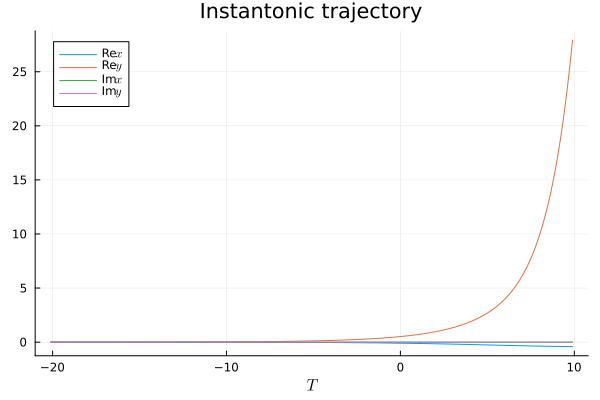

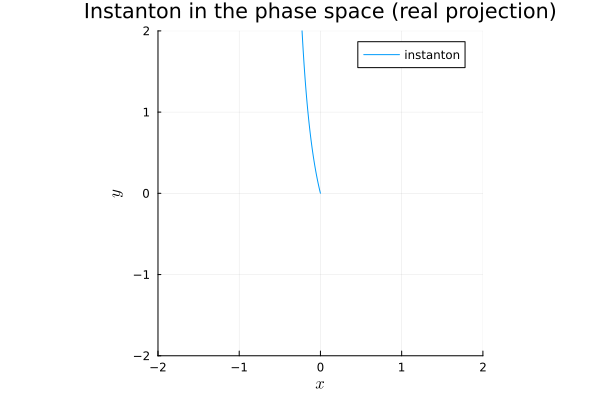

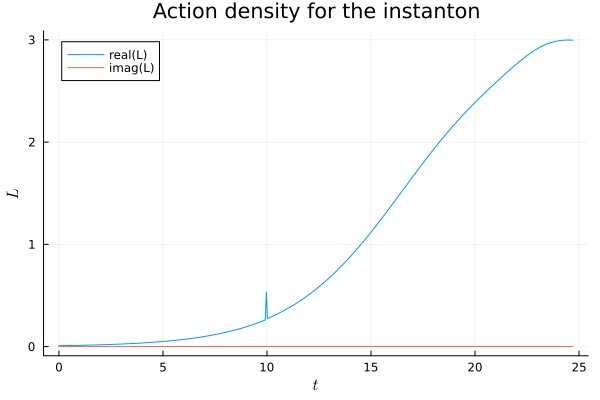


Total action = 25.884751754831765 + 6.4391893466747475e-15im


(25.884751754831765 + 6.4391893466747475e-15im, ComplexF64[-0.0003572795321815395 + 4.4188715159387757e-16im -0.0003635939421563982 + 4.357350094140658e-16im … -0.41165483013993126 + 3.72713791956101e-18im -0.41262342419016923 + 4.041832641337319e-18im; 0.001447326886433788 - 4.5105103858455e-17im 0.001472960119178787 - 4.2350373234295706e-17im … 26.9612116690858 - 1.8074005960313737e-15im 27.928261154998925 - 2.3020531480420057e-15im])

In [19]:
S_inst, sol = ST.instanton(system2,coord, x_init = 0.0, direction_guess=[0.00, 0.05], T_backward=10.0, T_forward=20.0, dt=0.05, show_action=true)

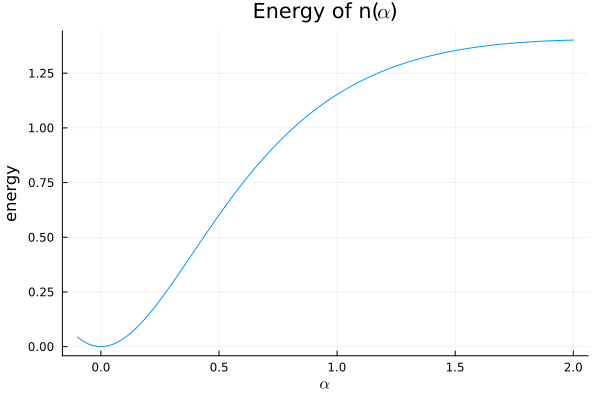

Imaginary part = 4.695405896726977e-16


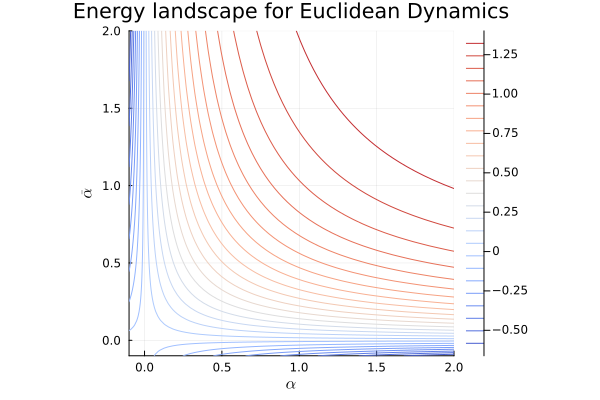

Imaginary part = 8.978494195644378e-16


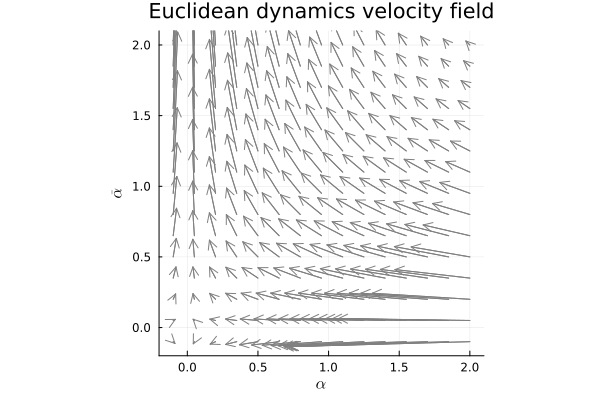

In [22]:
u, v = ST.uv(n_Sk)
coord = AlphaCoordinate(u,v)
ST.describe_collective_coordinate(system2, coord,xmin=-0.1,xmax=2.0)

In [31]:
sol = ST.solve_ivp([1.0,-0.5im], system2, coord, dt=0.05, T = 1.0)
ST.test_energy_conservation(sol, system2, coord)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


energy_diff = 6.226505645918532e-8
Energy conserved


6.226505645918532e-8

# Physical units

In [55]:
ST.test_energy_conservation(sol,system2,coord)

energy_diff = 2.7739588405701744e-11
Energy conserved


2.7739588405701744e-11

In [56]:
K = 1.6e-22 / (1e-34)

1.6e12

In [61]:
S_inst = 6
1/K * exp(20*S_inst)

8.151130489960201e39

# Old

In [160]:
ST.test_conj_reversal_swap_symmetry(system2,coord, dt=0.001)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:04
Progress: 100%|█████████████████████████████████████████| Time: 0:00:04


max_diff = 0.00011793133717171925

ERROR -------------------------------------> 
 ------------> occured for 

SquareLattice(30, 30)
PeriodicBoundary()
Hamiltonian parameters:
J1 = 1.0	J2 = -0.3	J3 = -0.2
K = 0.02
B_avg = 0.2	B_uniform = true

err = 0.00011793133717171925



# Parametric dependence

Let's focus on the dependence of the tunneling action $S_{inst}$ on a local magnetizing field. The field is constant on a circular region and has a Gaussian-like drop-off outside of the circle. The asymptotic field value is chosen large so that there can be no skyrmions outside the region. We observe that as the local field is increased to point where a skyrmion is no longer energetically stable, the instantonic action decreases.

Launching LLG relaxation for


Progress:   0%|                                         |  ETA: 0:03:36

SquareLattice(40, 40)
PeriodicBoundary()
Hamiltonian parameters:
J1 = 1.0	J2 = -0.3	J3 = -0.2
K = 0.02
B_avg = 0.182	B_uniform = false



Progress:  42%|█████████████████                        |  ETA: 0:01:34

could not find an improving step; stopped early


Progress: 100%|█████████████████████████████████████████| Time: 0:01:07


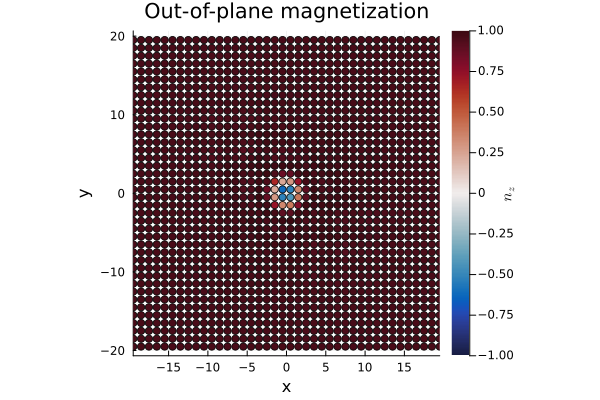

total charge Q = 0.6292701880421345

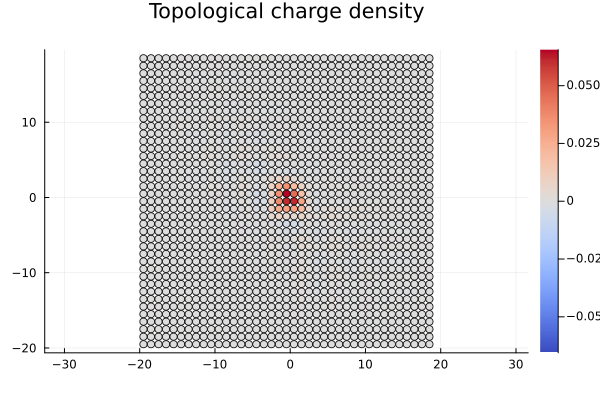

Energy = 1.215120925882502
Size = 76.74595346789079


LambdaCoordinate{Matrix{ComplexF64}}(ComplexF64[5.498305324481775e-5 + 0.1491832171713032im 0.10893930457448472 + 0.10277361802040343im … -0.15472536006672932 + 0.005104790406869654im -0.10917725567396415 + 0.10907028021670809im; 0.10215517423115389 + 0.10987728820486803im 0.1504681388458585 + 0.000992275692822958im … -0.1091084248717034 + 0.109003124786297im -0.005256560907021225 + 0.15470835853067594im; … ; -0.1453613837881031 - 0.0038506257192178926im -0.10447191092645651 + 0.1043862530537331im … -0.0008565299508705625 - 0.15046752505108058im -0.10266636603554921 - 0.10902036574996456im; -0.10201041324053527 + 0.10192914905998834im 0.0037342061224116727 + 0.14537736530971837im … -0.10979381492596593 - 0.10226313603012768im -0.14918221337003473 - 0.00018820842315906702im])

In [76]:
lattice = SquareLattice(40,40)
J1 = 1.0;	J2 = -0.3;	J3 = -0.2
K = 0.02;
# skyrmions disappear at B=0.23 and at B=0.16
B = ST.local_B_field(lattice, radius=3.0, relax_length=2.0, B_centre=0.22, B_inf=0.18)
#B = ST.uniform_B(0.18, lattice)

params = HamiltonianParameters(J1,J2,J3,K,B)
boundary = PeriodicBoundary()
system = System(params,lattice,boundary)

n_Sk = ST.skyrmion(system, annealing=true, LLG_relax=true, show_result=true, N_steps=30000) # it's faster to skip LLG_relax
#println("Energy = ", ST.H(n_Sk,system))
#n_Sk = ST.random_configuration(lattice)
#ST.anneal!(n_Sk,system, alpha=0.99, T0=2.0,T_minimal=1e-20,printing=false, max_iterations=10000000)
#ST.show_nz(n_Sk, lattice)
println("Energy = ", ST.H(n_Sk,system))
println("Size = ", ST.skyrmion_size(n_Sk))
#ST.show_topological_charge(n_Sk, system.lattice)
coord = LambdaCoordinate(ST.w_project(n_Sk))

In [161]:
data = DataFrame(B0=Float64[], Binf=Float64[], radius=Float64[], relax_length=Float64[], skyrmion_stable=Bool[], S_inst_Sk_aSk=Float64[], S_inst_Sk_FM=Float64[],
                skyrmion_size=Float64[])
push!(data, [B0,Binf,radius,relax_length,skyrmion_stable,S_inst_Sk_aSK,S_inst_Sk_FM, skyrmion_size])

LoadError: UndefVarError: `skyrmion_stable` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
@showprogress

In [ ]:
using ProgressMeter
data = DataFrame(B0=Float64[], Binf=Float64[], radius=Float64[], relax_length=Float64[], 
            skyrmion_stable=Bool[], skyrmion_energy=Float64[], topological_charge=Float64[],
            S_inst_Sk_aSk=ComplexF64[], S_inst_Sk_FM=ComplexF64[],skyrmion_size=Float64[])

lattice = SquareLattice(40,40)
boundary = PeriodicBoundary()
J1 = 1.0;	J2 = -0.3;	J3 = -0.2
K = 0.02;

# start with a decent approximation for the skyrmion ---> saves a lot of time in optimization
Binf = 0.18
B0_range = LinRange(0.15, 0.22, 5)
radius_range = LinRange(2,5,5)
B = ST.uniform_B(Binf,lattice)
params = HamiltonianParameters(J1,J2,J3,K,B)
system = System(params,lattice,boundary)
n_Sk0 = ST.skyrmion(system, annealing=false, LLG_relax=true, show_result=false)

@showprogress for B0 in B0_range, radius in radius_range
    print("\n"^10)
    println("B0 = $(B0) \t\t radius = $(radius)")
    relax_length = 2.0 # arbitrary

    ### ----- define the system and find the skyrmion minimum-----
    B = ST.local_B_field(lattice, radius=radius, relax_length=relax_length, B_centre=B0, B_inf=Binf)
    params = HamiltonianParameters(J1,J2,J3,K,B)
    system = System(params,lattice,boundary)

    n_Sk .= n_Sk0
    skyrmion_stable = ST.relax!(n_Sk, system, dt=0.2, N_steps=10000, adaptive_dt=true, dt_min=1e-20, graph=false, silent=false)
    show_nz(n_Sk)

    skyrmion_size = ST.skyrmion_size(n_Sk)
    #skyrmion_stable = ST.is_metastable(n_Sk,system, trials=1)
    skyrmion_energy = ST.H(n_Sk,system)
    topological_charge, Q_density = ST.topological_charge(n_Sk,lattice)

    ### ----- Sk -> aSk tunneling 

    coord = LambdaCoordinate(ST.w_project(n_Sk))
    #ST.show_energy_contours(system, coord, xmin=-1.2, xmax=1.2)
    S_inst_Sk_aSk, sol = ST.instanton(system,coord, x_init = 1.0, direction_guess=[0.00, -0.05], T_backward=20.0, T_forward=20.0, dt=0.05, show=false)
    

    ### ----- Sk -> FM  tunneling 
    S_inst_Sk_FM = 0.0

    push!(data, [B0,Binf,radius,relax_length,skyrmion_stable,skyrmion_energy,topological_charge,S_inst_Sk_aSk,S_inst_Sk_FM, skyrmion_size])
end 

Progress:   0%|                                         |  ETA: 0:01:19

Launching LLG relaxation for
SquareLattice(40, 40)
PeriodicBoundary()
Hamiltonian parameters:
J1 = 1.0	J2 = -0.3	J3 = -0.2
K = 0.02
B_avg = 0.18	B_uniform = true



Progress:  87%|███████████████████████████████████▋     |  ETA: 0:00:07

could not find an improving step; stopped early


Progress: 100%|█████████████████████████████████████████| Time: 0:00:45


...

 + 8.508986088387606e-6im
 y = 0.9500880233379511 + 7.408489828188927e-6im
sanity check : |H_inst-H0| = 4.7748665110935904e-12
-- Integrating forwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:03
Progress:   3%|█▎                                       |  ETA: 0:00:03

-- Integrating backwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:03
Progress: 100%|█████████████████████████████████████████| Time: 0:15:26


imaginary = 0.0003064517999270482

Total action = 8.36847905652859 + 0.0009751193627865157im


In [79]:
data

Row,B0,Binf,radius,relax_length,skyrmion_stable,skyrmion_energy,topological_charge,S_inst_Sk_aSk,S_inst_Sk_FM,skyrmion_size
,Float64,Float64,Float64,Float64,Bool,Float64,Float64,Complex…,Complex…,Float64
1,0.15,0.18,2.0,2.0,true,0.143214,0.77788,11.6533+1.4933e-6im,0.0+0.0im,52.2831
2,0.15,0.18,2.75,2.0,true,0.113769,0.778203,11.7164+1.4252e-6im,0.0+0.0im,53.3053
3,0.15,0.18,3.5,2.0,true,0.074833,0.776895,11.8335+1.71838e-6im,0.0+0.0im,55.1864
4,0.15,0.18,4.25,2.0,true,0.0202098,0.775867,12.0662+2.28861e-6im,0.0+0.0im,58.2514
5,0.15,0.18,5.0,2.0,true,-0.0432908,0.775368,12.5907+4.18527e-6im,0.0+0.0im,62.2364
6,0.1675,0.18,2.0,2.0,true,0.461094,0.760379,10.9784+1.40187e-6im,0.0+0.0im,50.8695
7,0.1675,0.18,2.75,2.0,true,0.449862,0.760488,11.001+1.41954e-6im,0.0+0.0im,51.2813
8,0.1675,0.18,3.5,2.0,true,0.435826,0.760057,11.0217+1.59345e-6im,0.0+0.0im,51.9826
9,0.1675,0.18,4.25,2.0,true,0.418844,0.759744,11.0251+1.90347e-6im,0.0+0.0im,52.9899


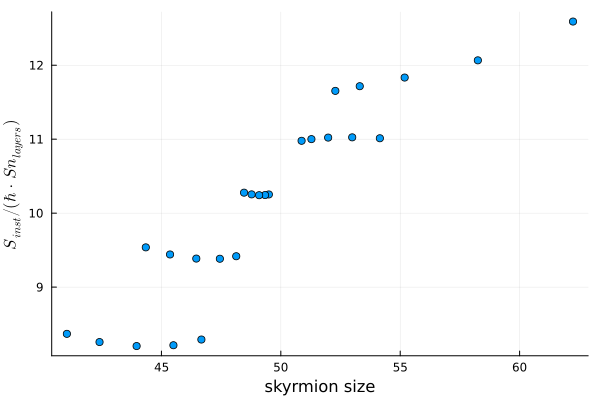

In [81]:
S = scatter(data.skyrmion_size, real.(data.S_inst_Sk_aSk), xlabel="skyrmion size", ylabel=L"$S_{inst}/(\hbar \cdot S n_{layers})$",legend=false)
display(S)

In [66]:
S = zeros(length(radius_range), length(B0_range))
for indr = 1:length(radius_range)
    for indB = 1:length(B0_range)
        continue
    end
end

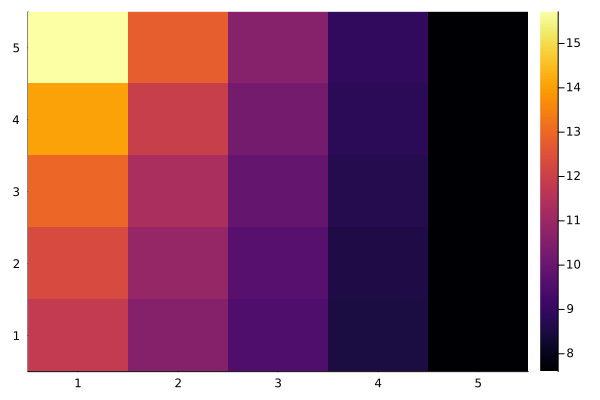

In [67]:
S = real.(data.S_inst_Sk_aSk)
heatmap(reshape(S, (5,5)))

In [68]:
real.(data.S_inst_Sk_aSk)

25-element Vector{Float64}:
 11.805948353283153
 12.302447383721283
 12.949885026591673
 14.056508969554237
 15.715753366429091
 10.559019051563352
 10.88651359344177
 11.30936637787239
 11.95200650181124
 12.769601673508816
  9.465535747307113
  9.657819654204067
  9.899313600757372
 10.225170418011665
 10.565701818639361
  8.490158444330138
  8.57491713096792
  8.677284750235819
  8.800797964308794
  8.91042199415617
  7.5973307540870385
  7.5973307540870385
  7.5973307540870385
  7.5973307540870385
  7.5973307540870385

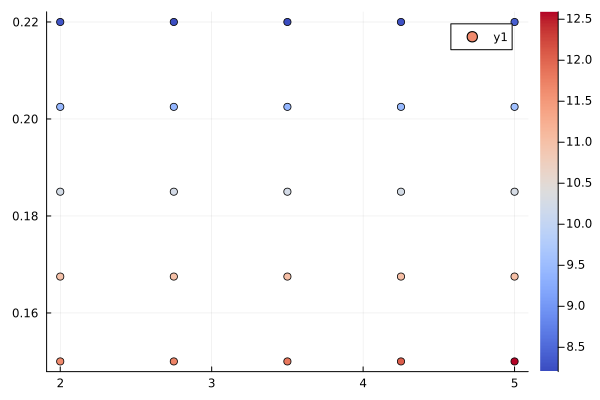

In [84]:
scatter(data.radius, data.B0, marker_z = real.(data.S_inst_Sk_aSk), marker_size=10, c=:coolwarm)

# Old

In [37]:
function four_fold_symmetrize!(n)
    # relevant only for square lattices
    nx = n.size[2]
    ny = n.size[3]
    for j=1:div(nx,2), i=1:div(ny,2)
        # the second quadrant
        k = i; l = ny+1-j
        n[1,k,l] = -n[1,i,j]
        n[2,k,l] = n[2,i,j]
        n[3,k,l] = n[3,i,j]
        # the third quadrant
        k = nx+1-i; l = j
        n[1,k,l] = n[1,i,j]
        n[2,k,l] = -n[2,i,j]
        n[3,k,l] = n[3,i,j]
        # the fourth quadrant
        k = nx+1-i; l = ny+1-j
        n[1,k,l] = -n[1,i,j]
        n[2,k,l] = -n[2,i,j]
        n[3,k,l] = n[3,i,j]
    end
end

four_fold_symmetrize! (generic function with 1 method)

In [101]:
function describe_symmetries(system,coord)
    x,y = randn(2)+im*randn(2)
    H0 = H(x,y,system,coord)
    H_vals = []
    for (x1,y1) in [(y,x), (-x,-y),(-y,-x),(conj(y), conj(x))]
        push!(H_vals, H(x,y,system,coord))
    end
end

describe_symmetries (generic function with 1 method)

In [6]:
let
    J1 = 1.0; J2 = -0.40; J3 = 1/16*(-J1+4*J2); K = 0.00
    boundary = FreeBoundary()

    nx = 50; ny = 50
    B = ST.uniform_B(nx,ny,0.12)
    B[25,25] = 100.0
    B[25,26] = 100.0
    #w0 = w_project(skyrmion_ansatz(nx,ny, 2.5))

    n0 = mean_field_skyrmion(nx,ny,J1,J2,J3,K,B,show=false,b=2.2)
    #n0 = random_configuration(nx,ny)
    w0 = ST.w_project(n0)

    # --- test symmetries ---
    del = zeros(4)
    for trial=1:1
        l = randn()+im*randn(); lb = randn()+im*randn(); 
        H0 = H_lambda(w0,l,lb,nx,ny,J1,J2,J3,K,B,boundary)
        H_val = []
        for (lambda,lambda_bar) in [(lb,l),(-l,-lb),(-lb,-l),(conj(lb),conj(l))]
            push!(H_val,H_lambda(w0,lambda,lambda_bar,nx,ny,J1,J2,J3,K,B,boundary))
        end
        del = del .+ [abs(H0-H_val[1]), abs(H0-H_val[2]), abs(H0-H_val[3]), abs(H0-conj(H_val[4]))]
    end
    threshold = 1e-9
    println("diff = ",del)
    println("\n H(l1,l2) = H(l2,l1) \t\t\t", del[1]<threshold, "\n H(l1,l2) = H(-l1,-l2) \t\t\t", del[2]<threshold, 
    "\n H(l1,l2) = H(-l2,-l1) \t\t\t", del[3]<threshold, 
    "\n H(l1,l2) = conj(H(conj(l2),conj(l2)))\t", del[4]<threshold)
end

diff = [9.094947017729282e-13, 9.094947017729282e-13, 0.0, 0.0]

 H(l1,l2) = H(l2,l1) 			true
 H(l1,l2) = H(-l1,-l2) 			true
 H(l1,l2) = H(-l2,-l1) 			true
 H(l1,l2) = conj(H(conj(l2),conj(l2)))	true


Let's consider a different choice of the collective coordinate. The stereographic projection I'm using can be written as
$$
w = \frac{\sin \frac{\theta}{2} e^{i\phi}}{\cos \frac{\theta}{2}}
$$
Calling the numerator $v$ and the denuminator $u$, we can introduce a collective coordinate according to
$$
w = \frac{v^+ + \eta v^-}{u^+ + \eta u^-}
$$

In [76]:
ST.test_eta_solver(up,um,vp,vm)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:14


u0 = ComplexF64[1.24262121121171 - 0.792584968481203im, -0.34645950953239957 + 0.11082857434023319im]
energy_diff = 1.5623576233217463e-9


Energy conserved ----------> OK
